# 05 Ablacion de predictores: clima vs rezagos de dengue

Objetivo: aislar cuanto predice cada bloque de informacion por separado. Regimen A usa
solo rezagos de los propios casos (autoregresivo); Regimen B usa solo variables climaticas
(y sus rezagos). Se corre cada familia de modelos bajo el regimen que aplica y se compara.

Todas las metricas son a un paso (nowcast). El R2 alto del regimen de rezagos viene casi
todo de la autocorrelacion de la serie (equivale a persistencia); el R2 del regimen de clima
es la senal real que aportan las variables climaticas por si solas. El pronostico anticipado
multi-paso esta en el notebook 03, seccion 9.

## 1 Carga y utilidades

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler

from statsmodels.tsa.statespace.sarimax import SARIMAX

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import torch
from pytorch_lightning.callbacks import EarlyStopping as EarlyStoppingPL
from darts import TimeSeries
from darts.models import NBEATSModel

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
tf.random.set_seed(42)
np.random.seed(42)

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / 'data'

df_dep = pd.read_parquet(DATA_DIR / 'processed' / 'dataset_modelado_magdalena.parquet')
df_dep = df_dep.sort_values('fecha_semana').reset_index(drop=True)
df_dep['amplitud'] = df_dep['t2m_max'] - df_dep['t2m_min']
print('Shape:', df_dep.shape)
print('Rango:', df_dep['fecha_semana'].min().date(), '->', df_dep['fecha_semana'].max().date())

Shape: (940, 10)
Rango: 2006-12-31 -> 2024-12-29


In [2]:
def compute_metrics(y_true, y_pred) -> dict:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    r2   = float(r2_score(y_true, y_pred))
    mask = y_true != 0
    mape = float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100) if mask.any() else float('nan')
    return {'RMSE': round(rmse, 3), 'MAE': round(mae, 3), 'MAPE': round(mape, 2), 'R2': round(r2, 4)}

def print_metrics(nombre, m):
    print(f'{nombre:32s} RMSE={m["RMSE"]:7.2f} | MAE={m["MAE"]:6.2f} | MAPE={m["MAPE"]:6.2f}% | R2={m["R2"]:6.4f}')

## 2 Split temporal (identico al notebook 03)

In [3]:
TRAIN_FRAC, TEST_FRAC = 0.70, 0.30
n = len(df_dep)
n_resto = round(n * TEST_FRAC)

idx_train, idx_resto = list(TimeSeriesSplit(n_splits=2, test_size=n_resto).split(df_dep))[-1]
df_train_dep = df_dep.iloc[idx_train].copy()
df_resto = df_dep.iloc[idx_resto].copy()

n_val = len(df_resto) // 2
df_val_dep = df_resto.iloc[:n_val].copy()
df_test_dep = df_resto.iloc[n_val:].copy()

FECHAS_TRAIN = set(df_train_dep['fecha_semana'])
FECHAS_VAL   = set(df_val_dep['fecha_semana'])
FECHAS_TEST  = set(df_test_dep['fecha_semana'])
df_trainval_dep = pd.concat([df_train_dep, df_val_dep]).sort_values('fecha_semana')
FECHAS_TRAINVAL = FECHAS_TRAIN | FECHAS_VAL

for nombre, d in [('Train', df_train_dep), ('Val', df_val_dep), ('Test', df_test_dep)]:
    print(f'{nombre:5s}: {len(d):4d} sem ({d["fecha_semana"].dt.year.min()}-{d["fecha_semana"].dt.year.max()}) | {len(d)/n:.1%}')

Train:  658 sem (2006-2019) | 70.0%
Val  :  141 sem (2019-2022) | 15.0%
Test :  141 sem (2022-2024) | 15.0%


## 3 Los dos regimenes de predictores

Mismo set de clima reconstruido y mismos rezagos que el nb 03. Regimen A = solo `casos_lag*`;
Regimen B = solo `<clima>_lag*`. Ningun modelo mezcla los dos bloques.

In [4]:
CLIMA_VARS  = ['precipitacion', 'amplitud', 't2m_media']
LAGS_CLIMA  = [4, 8, 12, 16]
LAGS_TARGET = [1, 2, 4, 8]

def build_features(serie: pd.DataFrame) -> pd.DataFrame:
    out = serie.copy().sort_values('fecha_semana').reset_index(drop=True)
    for var in CLIMA_VARS:
        for lag in LAGS_CLIMA:
            out[f'{var}_lag{lag}'] = out[var].shift(lag)
    for lag in LAGS_TARGET:
        out[f'casos_lag{lag}'] = out['casos'].shift(lag)
    return out.dropna().reset_index(drop=True)

df_feat = build_features(df_dep)
FEATURES_CLIMA = [f'{v}_lag{l}' for v in CLIMA_VARS for l in LAGS_CLIMA]
FEATURES_LAGS  = [f'casos_lag{l}' for l in LAGS_TARGET]

df_trainval_feat = df_feat[df_feat['fecha_semana'].isin(FECHAS_TRAINVAL)].copy()
df_test_feat     = df_feat[df_feat['fecha_semana'].isin(FECHAS_TEST)].copy()
y_trainval = df_trainval_feat['casos']
y_test     = df_test_feat['casos']

print('Regimen B (solo clima):', FEATURES_CLIMA)
print('Regimen A (solo lags) :', FEATURES_LAGS)
print('Test:', len(df_test_feat), 'semanas')

Regimen B (solo clima): ['precipitacion_lag4', 'precipitacion_lag8', 'precipitacion_lag12', 'precipitacion_lag16', 'amplitud_lag4', 'amplitud_lag8', 'amplitud_lag12', 'amplitud_lag16', 't2m_media_lag4', 't2m_media_lag8', 't2m_media_lag12', 't2m_media_lag16']
Regimen A (solo lags) : ['casos_lag1', 'casos_lag2', 'casos_lag4', 'casos_lag8']
Test: 141 semanas


## 4 Utilidades de evaluacion

In [5]:
# Colector de resultados: nombre -> (regimen, metricas)
resultados = {}
FIG = (13, 3.3)

def _plot(fechas, real, pred, nombre, m, color):
    fig, ax = plt.subplots(figsize=FIG)
    ax.plot(fechas, real, color='black', label='Real')
    ax.plot(fechas, pred, color=color, ls='--', label=nombre)
    ax.set_title(f'{nombre} - RMSE={m["RMSE"]} | MAE={m["MAE"]} | R2={m["R2"]}')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

def eval_tree(modelo, feats, nombre, regimen, color):
    modelo.fit(df_trainval_feat[feats], y_trainval)
    pred = modelo.predict(df_test_feat[feats]).clip(min=0)
    m = compute_metrics(y_test.values, pred)
    resultados[nombre] = (regimen, m)
    _plot(df_test_feat['fecha_semana'], y_test.values, pred, nombre, m, color)
    print_metrics(nombre, m)
    return m

def nuevo_xgb():
    return XGBRegressor(random_state=42, n_jobs=-1, max_depth=3, learning_rate=0.05,
                        n_estimators=300, min_child_weight=5, subsample=0.8,
                        colsample_bytree=0.8, reg_lambda=3)

def nuevo_lgbm():
    return LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1, num_leaves=15,
                         learning_rate=0.03, n_estimators=300, min_child_samples=20,
                         subsample=0.8, subsample_freq=1, colsample_bytree=0.8, reg_lambda=3)

def eval_sarimax(order, seasonal_order, feats, nombre, regimen, color):
    base = df_feat.set_index('fecha_semana').copy()
    base['casos_log'] = np.log1p(base['casos'])
    entreno = base[base.index.isin(FECHAS_TRAINVAL)]
    test    = base[base.index.isin(FECHAS_TEST)]
    y_tr = entreno['casos_log']; y_te = test['casos_log']; y_real = test['casos']
    X_tr = entreno[feats].values if feats else None
    X_te = test[feats].values if feats else None

    fit = SARIMAX(y_tr, exog=X_tr, order=order, seasonal_order=seasonal_order,
                  enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    modelo_test = fit.append(y_te, exog=X_te, refit=False)
    pred_log = modelo_test.predict(start=y_te.index[0], end=y_te.index[-1], exog=X_te, dynamic=False)
    pred = np.expm1(pred_log).clip(lower=0)
    m = compute_metrics(y_real.values, pred.values)
    resultados[nombre] = (regimen, m)
    _plot(y_real.index, y_real.values, pred.values, nombre, m, color)
    print_metrics(nombre, m)
    return m

In [6]:
# LSTM generico: el target es siempre casos (log1p). Las features de entrada pueden
# incluir o no a los propios casos; asi el mismo codigo sirve para el regimen de lags
# (ventana de casos) y el de clima (ventana de clima -> casos).
WINDOW = 12

def preparar_lstm(input_feats, window=WINDOW):
    base = df_dep.set_index('fecha_semana').sort_index().copy()
    base['casos_log'] = np.log1p(base['casos'])
    fechas = base.index
    pos_val  = fechas.isin(FECHAS_TRAIN).sum()
    pos_test = pos_val + fechas.isin(FECHAS_VAL).sum()

    Xdf = pd.DataFrame(index=base.index)
    for f in input_feats:
        Xdf[f] = base['casos_log'] if f == 'casos' else base[f]

    x_scaler = MinMaxScaler().fit(Xdf.iloc[:pos_val])
    Xs = x_scaler.transform(Xdf)
    y_scaler = MinMaxScaler().fit(base[['casos_log']].iloc[:pos_val])
    ys = y_scaler.transform(base[['casos_log']]).flatten()

    Xseq, yseq = [], []
    for i in range(window, len(base)):
        Xseq.append(Xs[i - window:i]); yseq.append(ys[i])
    Xseq, yseq = np.array(Xseq), np.array(yseq)

    sp = dict(
        Xtr=Xseq[:pos_val - window],       ytr=yseq[:pos_val - window],
        Xva=Xseq[pos_val - window:pos_test - window], yva=yseq[pos_val - window:pos_test - window],
        Xte=Xseq[pos_test - window:],      yte=yseq[pos_test - window:],
    )
    fechas_test = fechas[pos_test:]

    def inv(a):
        a = np.asarray(a).reshape(-1, 1)
        return np.expm1(y_scaler.inverse_transform(a).flatten()).clip(min=0)

    return sp, inv, fechas_test

def crear_lstm(n_feats, units=(64, 32), dropout=0.2):
    m = Sequential()
    m.add(LSTM(units[0], activation='tanh', return_sequences=True, input_shape=(WINDOW, n_feats)))
    m.add(Dropout(dropout))
    m.add(LSTM(units[1], activation='tanh'))
    m.add(Dropout(dropout))
    m.add(Dense(1))
    m.compile(optimizer='adam', loss='mean_absolute_error')
    return m

def eval_lstm(input_feats, nombre, regimen, color):
    sp, inv, fechas_test = preparar_lstm(input_feats)
    tf.keras.utils.set_random_seed(42)
    model = crear_lstm(len(input_feats))
    cbs = [EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
           ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-5)]
    model.fit(sp['Xtr'], sp['ytr'], validation_data=(sp['Xva'], sp['yva']),
              epochs=200, batch_size=16, callbacks=cbs, verbose=0)
    pred = inv(model.predict(sp['Xte'], verbose=0).flatten())
    real = inv(sp['yte'])
    m = compute_metrics(real, pred)
    resultados[nombre] = (regimen, m)
    _plot(fechas_test[:len(real)], real, pred, nombre, m, color)
    print_metrics(nombre, m)
    return m

In [7]:
# N-BEATS es autoregresivo por construccion (descompone la historia del propio target en
# una base de tendencia + estacionalidad). Su forma natural es el regimen de solo casos.
def eval_nbeats_lags(nombre='N-BEATS (solo casos)', color='#1f77b4'):
    serie_log = np.log1p(df_dep.set_index('fecha_semana')['casos'])
    ts_full = TimeSeries.from_series(serie_log, freq='W-SUN')
    fechas = df_dep['fecha_semana']
    n_train = fechas.isin(FECHAS_TRAIN).sum()
    n_val   = fechas.isin(FECHAS_VAL).sum()
    ts_train = ts_full[:n_train]
    ts_val   = ts_full[n_train:n_train + n_val]
    ts_test  = ts_full[n_train + n_val:]

    accel = 'gpu' if torch.cuda.is_available() else 'cpu'
    early = EarlyStoppingPL(monitor='val_loss', patience=20, min_delta=1e-4, mode='min')
    model = NBEATSModel(input_chunk_length=26, output_chunk_length=1, num_blocks=1,
                        layer_widths=128, n_epochs=200, batch_size=16, random_state=42,
                        pl_trainer_kwargs={'enable_progress_bar': False, 'accelerator': accel,
                                           'devices': 1, 'callbacks': [early]})
    model.fit(ts_train, val_series=ts_val, verbose=False)

    pred_ts = model.historical_forecasts(series=ts_full, start=n_train + n_val,
                start_format='position', forecast_horizon=1, stride=1, retrain=False,
                last_points_only=True, verbose=False)
    pred_al = pred_ts.slice_intersect(ts_test)
    real_al = ts_test.slice_intersect(pred_ts)
    pred = np.expm1(pred_al.values().flatten()).clip(min=0)
    real = np.expm1(real_al.values().flatten()).clip(min=0)
    m = compute_metrics(real, pred)
    resultados[nombre] = ('solo lags', m)
    _plot(pred_al.time_index, real, pred, nombre, m, color)
    print_metrics(nombre, m)
    return m

## 5 Baseline: persistencia (y_t = y_{t-1})

In [8]:
serie = df_dep.set_index('fecha_semana')['casos']
persist_pred = serie.shift(1).reindex(df_test_feat['fecha_semana']).values
m_persist = compute_metrics(y_test.values, persist_pred)
resultados['Persistencia'] = ('baseline', m_persist)
print_metrics('Persistencia (y_t-1)', m_persist)

Persistencia (y_t-1)             RMSE=  13.21 | MAE=  9.95 | MAPE= 26.11% | R2=0.8477


## 6 Regimen A - solo rezagos de dengue

Autoregresivo puro: la unica entrada es el pasado de la propia serie de casos. Si estos
modelos igualan a persistencia, el R2 alto es autocorrelacion, no habilidad.

### 6.1 ARIMA y SARIMA

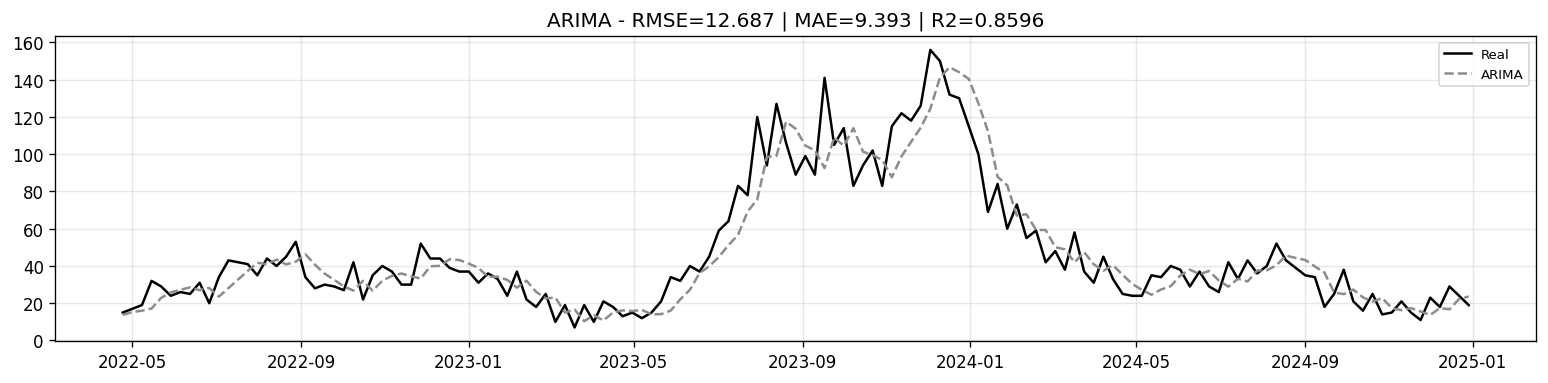

ARIMA                            RMSE=  12.69 | MAE=  9.39 | MAPE= 23.54% | R2=0.8596


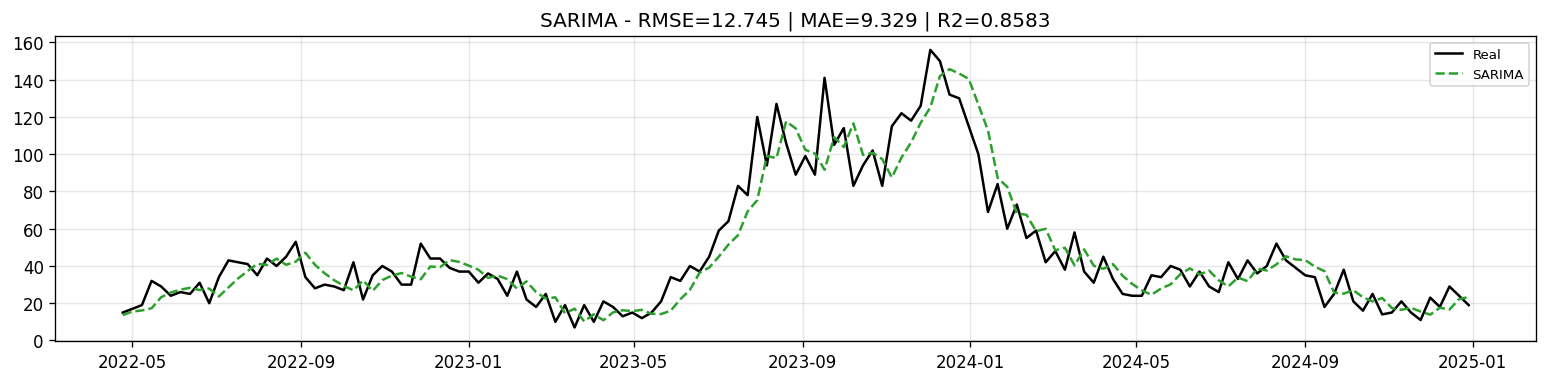

SARIMA                           RMSE=  12.74 | MAE=  9.33 | MAPE= 23.51% | R2=0.8583


In [9]:
ORDER = (2, 1, 2)
eval_sarimax(ORDER, (0, 0, 0, 0),  [], 'ARIMA',  'solo lags', '#8c8c8c')
eval_sarimax(ORDER, (1, 0, 1, 52), [], 'SARIMA', 'solo lags', '#2ca02c');

### 6.2 Arboles (solo casos_lag)

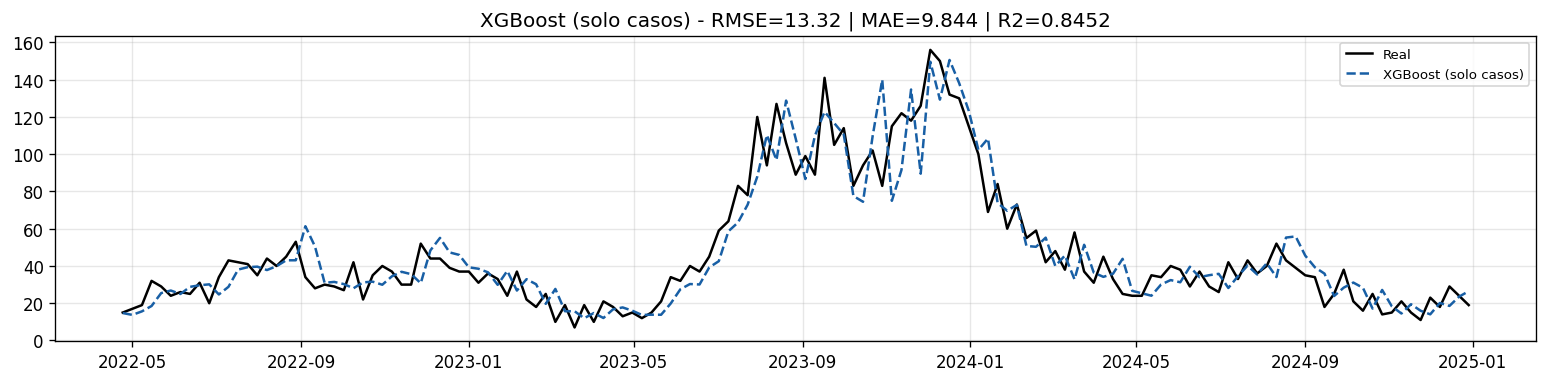

XGBoost (solo casos)             RMSE=  13.32 | MAE=  9.84 | MAPE= 25.60% | R2=0.8452


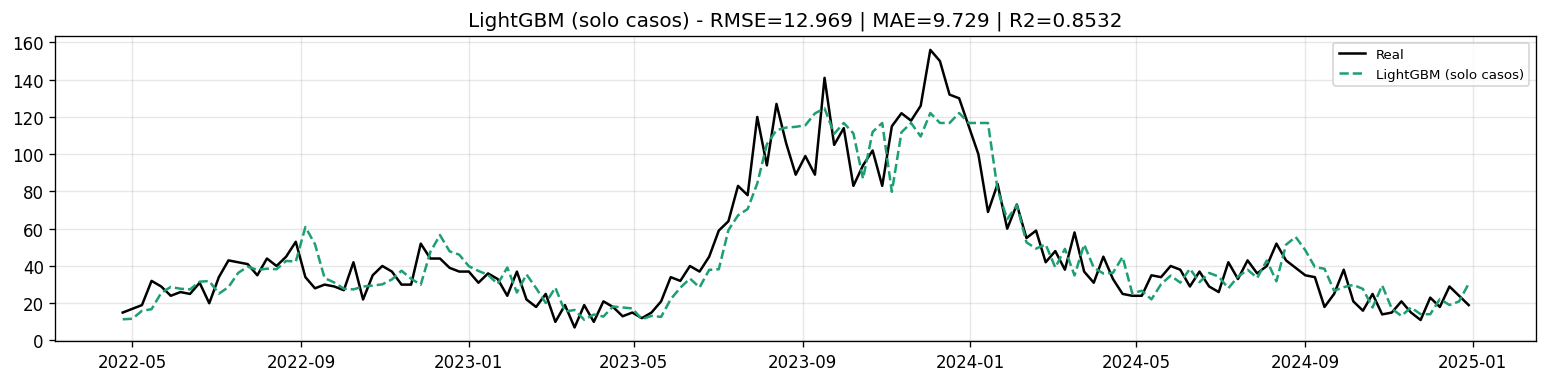

LightGBM (solo casos)            RMSE=  12.97 | MAE=  9.73 | MAPE= 26.18% | R2=0.8532


In [10]:
eval_tree(nuevo_xgb(),  FEATURES_LAGS, 'XGBoost (solo casos)',  'solo lags', '#185FA5')
eval_tree(nuevo_lgbm(), FEATURES_LAGS, 'LightGBM (solo casos)', 'solo lags', '#1D9E75');

### 6.3 LSTM (ventana de casos)

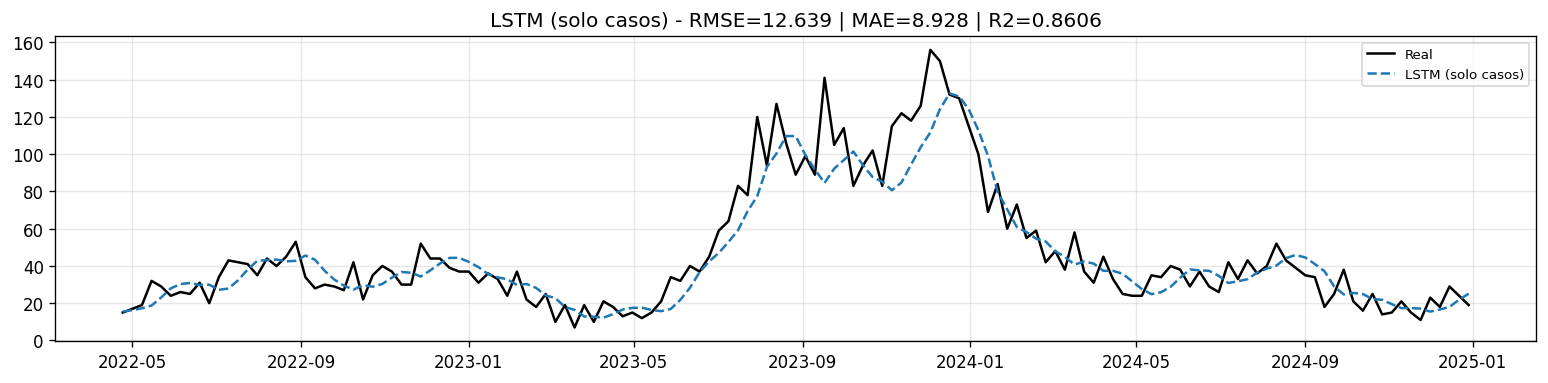

LSTM (solo casos)                RMSE=  12.64 | MAE=  8.93 | MAPE= 22.74% | R2=0.8606


In [11]:
eval_lstm(['casos'], 'LSTM (solo casos)', 'solo lags', '#1f77b4');

### 6.4 N-BEATS (solo casos)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 3050 6GB Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


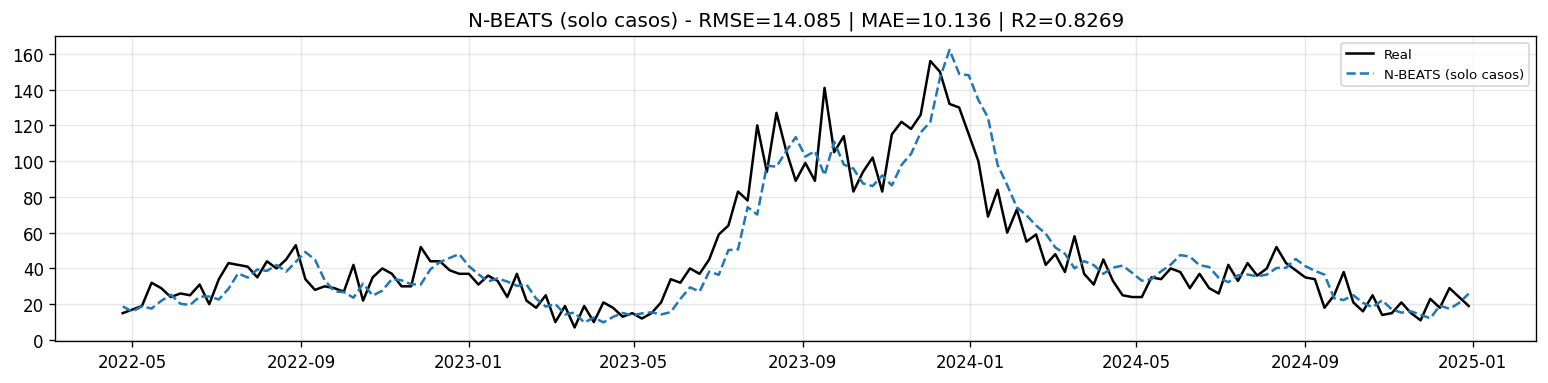

N-BEATS (solo casos)             RMSE=  14.09 | MAE= 10.14 | MAPE= 24.53% | R2=0.8269


In [12]:
eval_nbeats_lags();

## 7 Regimen B - solo clima

La unica entrada son rezagos de las variables climaticas (4-16 semanas). No se le da ningun
valor pasado de casos: mide cuanto predice el clima por si solo.

### 7.1 Regresion lineal (clima)

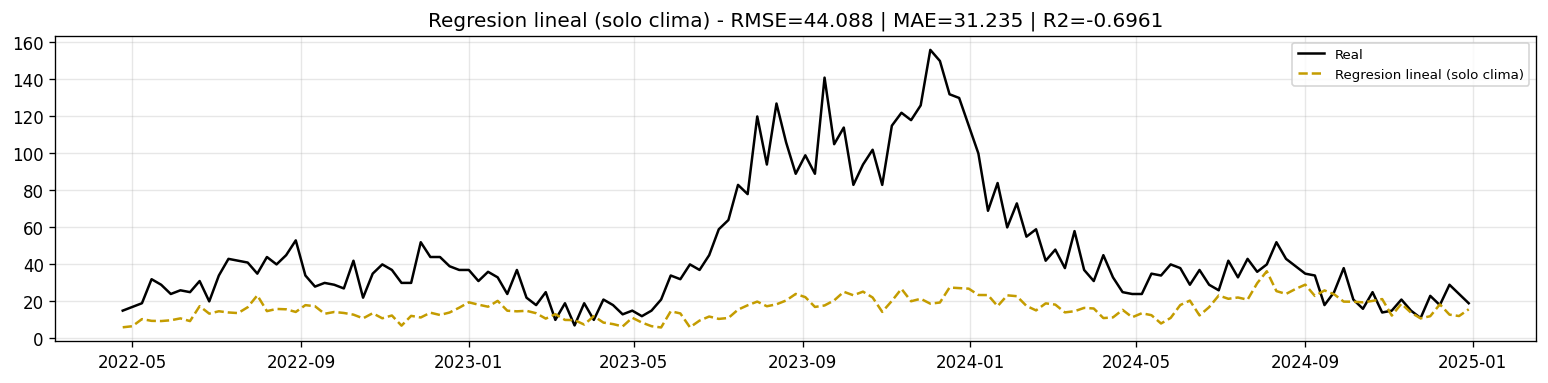

Regresion lineal (solo clima)    RMSE=  44.09 | MAE= 31.23 | MAPE= 55.95% | R2=-0.6961


In [13]:
lin = LinearRegression().fit(df_trainval_feat[FEATURES_CLIMA], np.log1p(y_trainval))
pred_lin = np.expm1(lin.predict(df_test_feat[FEATURES_CLIMA])).clip(min=0)
m_lin = compute_metrics(y_test.values, pred_lin)
resultados['Regresion lineal (solo clima)'] = ('solo clima', m_lin)
_plot(df_test_feat['fecha_semana'], y_test.values, pred_lin, 'Regresion lineal (solo clima)', m_lin, '#c49c00')
print_metrics('Regresion lineal (solo clima)', m_lin)

### 7.2 Arboles (solo lags de clima)

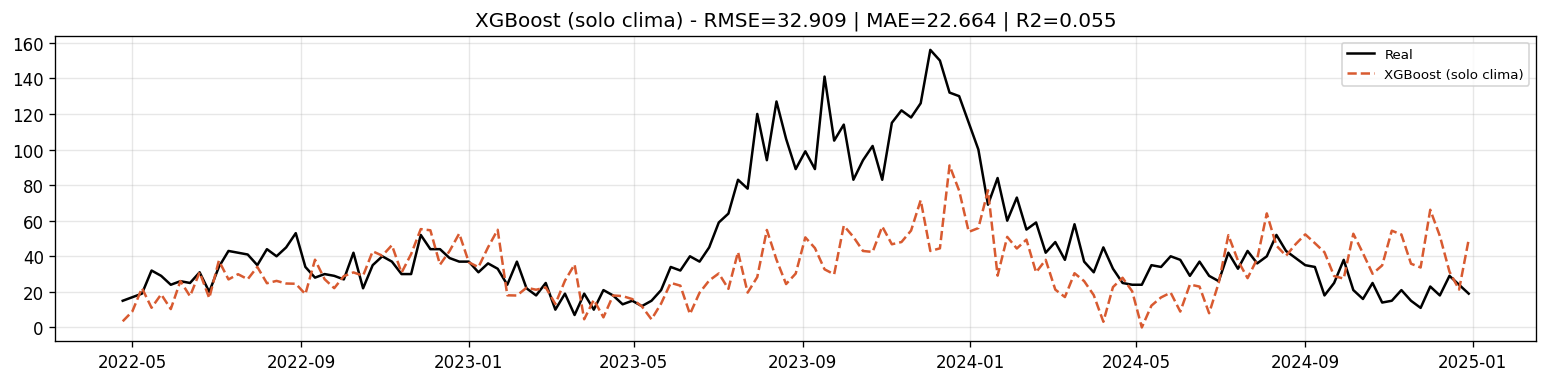

XGBoost (solo clima)             RMSE=  32.91 | MAE= 22.66 | MAPE= 50.59% | R2=0.0550


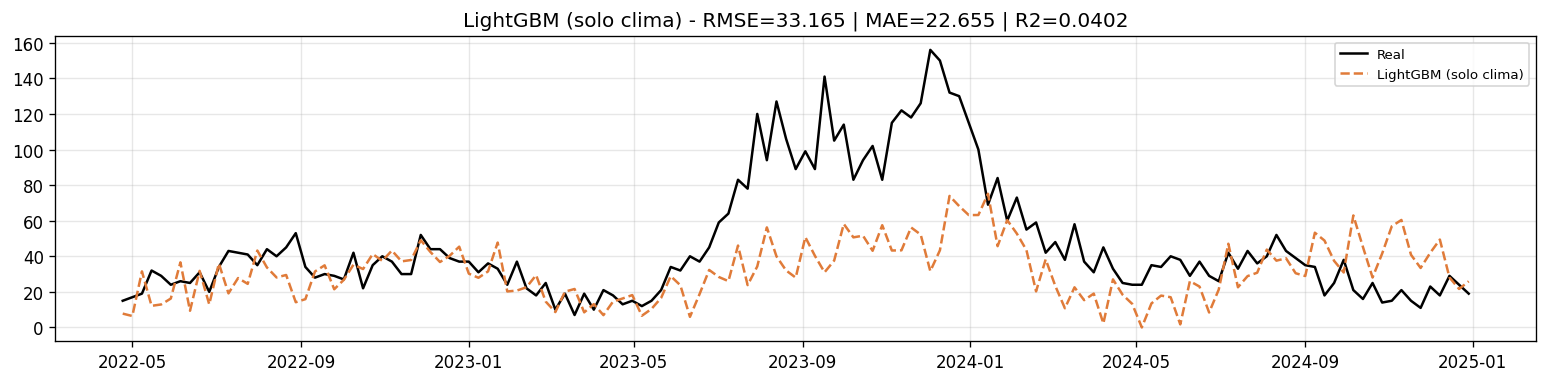

LightGBM (solo clima)            RMSE=  33.16 | MAE= 22.66 | MAPE= 49.89% | R2=0.0402


In [14]:
eval_tree(nuevo_xgb(),  FEATURES_CLIMA, 'XGBoost (solo clima)',  'solo clima', '#D85A30')
eval_tree(nuevo_lgbm(), FEATURES_CLIMA, 'LightGBM (solo clima)', 'solo clima', '#e07b39');

### 7.3 LSTM (ventana de clima)

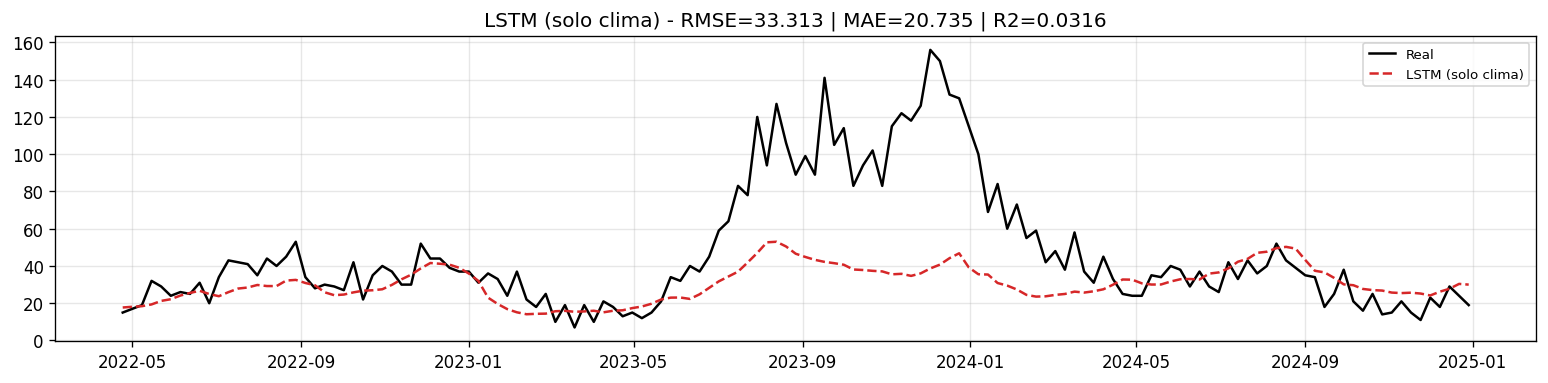

LSTM (solo clima)                RMSE=  33.31 | MAE= 20.73 | MAPE= 36.08% | R2=0.0316


In [15]:
eval_lstm(CLIMA_VARS, 'LSTM (solo clima)', 'solo clima', '#d62728');

### 7.4 N-BEATS con clima: no aplica

N-BEATS predice a partir de la historia del propio target; sin los casos pasados no hay nada
que descomponer, y las covariables solas no lo alimentan. El regimen de solo clima en la parte
profunda lo cubre el LSTM (7.3), que si acepta una ventana puramente climatica.

## 8 Comparacion clima vs lags

In [19]:
orden = ['Persistencia', 'ARIMA', 'SARIMA',
         'XGBoost (solo casos)', 'LightGBM (solo casos)', 'LSTM (solo casos)', 'N-BEATS (solo casos)',
          'XGBoost (solo clima)', 'LightGBM (solo clima)', 'LSTM (solo clima)']

df_comp = pd.DataFrame({nom: {'regimen': reg, **m} for nom, (reg, m) in resultados.items()}).T
df_comp = df_comp.loc[[o for o in orden if o in df_comp.index]]
df_comp[['RMSE', 'MAE', 'MAPE', 'R2']] = df_comp[['RMSE', 'MAE', 'MAPE', 'R2']].astype(float)
print(df_comp.to_string())

                          regimen    RMSE     MAE   MAPE      R2
Persistencia             baseline  13.211   9.950  26.11  0.8477
ARIMA                   solo lags  12.687   9.393  23.54  0.8596
SARIMA                  solo lags  12.745   9.329  23.51  0.8583
XGBoost (solo casos)    solo lags  13.320   9.844  25.60  0.8452
LightGBM (solo casos)   solo lags  12.969   9.729  26.18  0.8532
LSTM (solo casos)       solo lags  12.639   8.928  22.74  0.8606
N-BEATS (solo casos)    solo lags  14.085  10.136  24.53  0.8269
XGBoost (solo clima)   solo clima  32.909  22.664  50.59  0.0550
LightGBM (solo clima)  solo clima  33.165  22.655  49.89  0.0402
LSTM (solo clima)      solo clima  33.313  20.735  36.08  0.0316


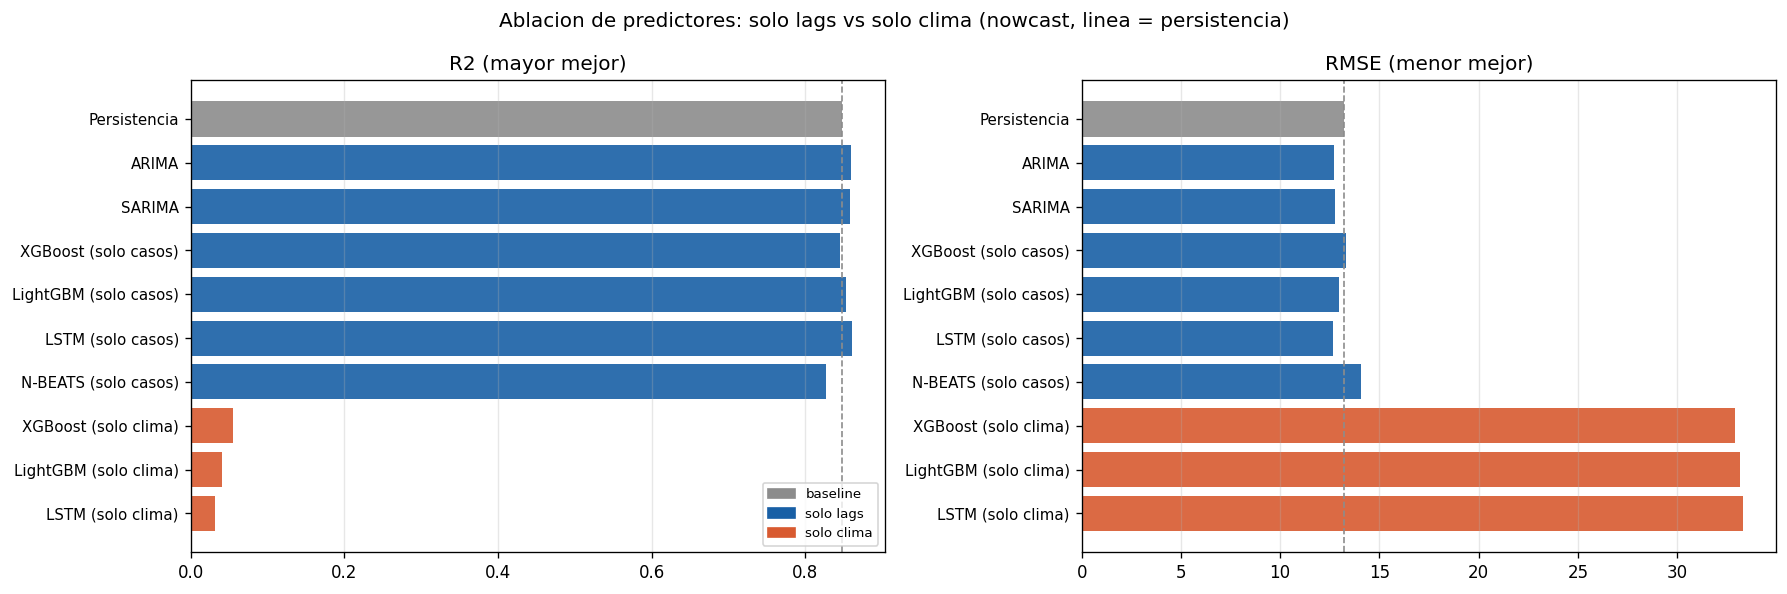

In [20]:
COLOR_REG = {'baseline': '#8c8c8c', 'solo lags': '#185FA5', 'solo clima': '#D85A30'}
colores = [COLOR_REG[r] for r in df_comp['regimen']]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, met, titulo in [(axes[0], 'R2', 'R2 (mayor mejor)'), (axes[1], 'RMSE', 'RMSE (menor mejor)')]:
    vals = df_comp[met].values
    ax.barh(range(len(df_comp)), vals, color=colores, alpha=0.9)
    ax.set_yticks(range(len(df_comp))); ax.set_yticklabels(df_comp.index, fontsize=9)
    ax.invert_yaxis(); ax.set_title(titulo); ax.grid(axis='x', alpha=0.3)
    ref = df_comp.loc['Persistencia', met]
    ax.axvline(ref, color='#8c8c8c', ls='--', lw=1)

from matplotlib.patches import Patch
handles = [Patch(color=c, label=r) for r, c in COLOR_REG.items()]
axes[0].legend(handles=handles, fontsize=8, loc='lower right')
plt.suptitle('Ablacion de predictores: solo lags vs solo clima (nowcast, linea = persistencia)')
plt.tight_layout(); plt.show()